In [47]:
import random
import gymnasium as gym # contains the cartpole-v1 pendulum environment
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim

import time
from collections import deque

In [48]:
environment=gym.make('CartPole-v1',render_mode='human') # create the environment

In [49]:
#Some playing around
state, info = environment.reset()
state # array  of cart_position, cart_velocity, pole_angle, pole_angular_velocity
number_of_actions= environment.action_space.n
print(number_of_actions) # 2 left or right 0 or 1

2


In [50]:
# Build the Q-network instead of a huge Q-table(main point of deep-Q learning use a neural network as the approximation of the Q function)
class DeepQ(nn.Module):
  def __init__(self, state_size, number_of_actions):
    super().__init__()
    self.layers= nn.Sequential(
        nn.Linear(state_size, 64),
        nn.ReLU(),
        nn.Linear(64, 32),
        nn.ReLU(),
        nn.Linear(32, number_of_actions)
    )

  def forward(self, state):
    return self.layers(state)


In [51]:
device='cpu'
model= DeepQ(4, 2).to(device) # state_size=4, no of actions=2
optimizer= optim.Adam(model.parameters(), lr=0.001)

In [52]:
loss_function = nn.MSELoss() #mean square error as loss

In [53]:
replay_memory= deque(maxlen=10000) # store the experiences

In [54]:
# Choosing actions intially by greedy then by epsilon greedy
def choose_action(state):
  if random.random() < epsilon :
    return environment.action_space.sample()

  state_tensor= torch.FloatTensor(state).unsqueeze(0).to(device)

  with torch.no_grad():
    q_values = model(state_tensor)

  action= torch.argmax(q_values).detach().item() #whichever action has higher value

  return action

In [55]:
batch_size = 64
gamma = 0.99
epsilon=1

def train_network():

  batch = random.sample(replay_memory, batch_size) # instead of only the last experience, sample last 64 randomly
  states, actions,rewards, next_states, dones = zip(*batch) # separate each column into arrays

  # convert all to pytorch tensors to work with them
  states = torch.as_tensor(np.array(states), dtype=torch.float32, device=device)
  next_states = torch.as_tensor(np.array(next_states), dtype=torch.float32, device=device)
    
  actions = torch.as_tensor(actions, dtype=torch.long, device=device)
  rewards = torch.as_tensor(rewards, dtype=torch.float32, device=device)
  dones = torch.as_tensor(dones, dtype=torch.float32, device=device)

  all_q_values = model(states) # ask model for all q values of every action in every state

  predicted_q_values = all_q_values.gather(dim=1, index=actions.unsqueeze(1)).squeeze(1) # keep only the q value of the action that was taken

  # Compute the target from Bellman Expectation

  with torch.no_grad():
    future_q_values= model(next_states) # ask model for all q values of every action in every possible future state
    maximum_future_q=future_q_values.max(dim=1)[0]

    target_q_values=(rewards + gamma*maximum_future_q*(1-dones)) #Bellman

  loss= loss_function(predicted_q_values, target_q_values) # compute diff between the 2 q values

  # backprop and train the model
  optimizer.zero_grad(set_to_none=True)
  loss.backward()
  optimizer.step()

In [56]:
episode_rewards = []

for episode in range(100):
    state, info = environment.reset()
    done = False
    episode_reward = 0

    while not done:
        action = choose_action(state)
        next_state, reward, terminated, truncated, info = environment.step(action)
        episode_reward += reward
        done = terminated or truncated
        time.sleep(0.02)
        replay_memory.append(
            (
                state,
                action,
                reward,
                next_state,
                done
            )
        )
        state = next_state
        if len(replay_memory) >= batch_size: # don't train till sufficient no of experiences present
            train_network()

    episode_rewards.append(episode_reward)
    print(episode, "reward:", episode_reward)
    epsilon = max(
        0.01,
        epsilon * 0.995
    )
environment.close()

0 reward: 25.0
1 reward: 19.0
2 reward: 22.0
3 reward: 24.0
4 reward: 15.0
5 reward: 17.0
6 reward: 28.0
7 reward: 26.0
8 reward: 22.0
9 reward: 30.0
10 reward: 21.0
11 reward: 39.0
12 reward: 13.0
13 reward: 47.0
14 reward: 17.0
15 reward: 35.0
16 reward: 28.0
17 reward: 26.0
18 reward: 11.0
19 reward: 18.0
20 reward: 15.0
21 reward: 27.0
22 reward: 37.0
23 reward: 13.0
24 reward: 15.0
25 reward: 15.0
26 reward: 20.0
27 reward: 18.0
28 reward: 23.0
29 reward: 16.0
30 reward: 35.0
31 reward: 54.0
32 reward: 26.0
33 reward: 11.0
34 reward: 22.0
35 reward: 26.0
36 reward: 22.0
37 reward: 27.0
38 reward: 16.0
39 reward: 27.0
40 reward: 37.0
41 reward: 17.0
42 reward: 37.0
43 reward: 29.0
44 reward: 22.0
45 reward: 37.0
46 reward: 37.0
47 reward: 31.0
48 reward: 52.0
49 reward: 19.0
50 reward: 20.0
51 reward: 21.0
52 reward: 29.0
53 reward: 32.0
54 reward: 45.0
55 reward: 28.0
56 reward: 39.0
57 reward: 69.0
58 reward: 40.0
59 reward: 52.0
60 reward: 32.0
61 reward: 26.0
62 reward: 13.0
63

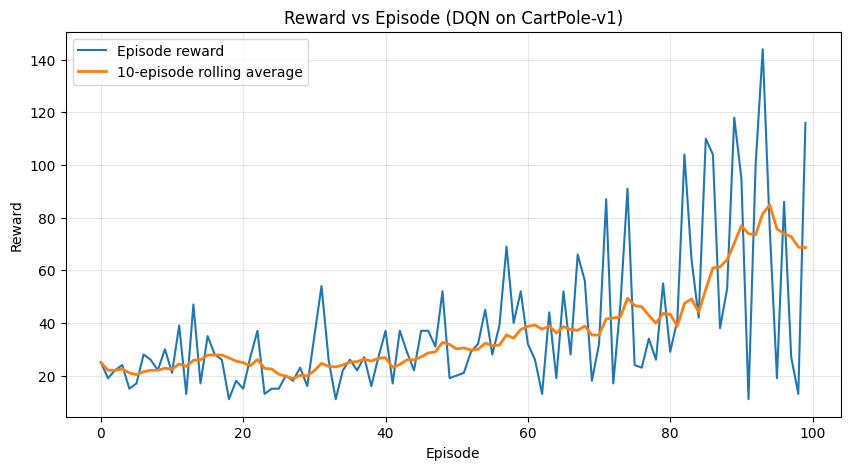

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(episode_rewards, label="Episode reward")

# rolling average makes the trend easier to see through the noise
window = 10
if len(episode_rewards) >= window:
    rolling_avg = [
        sum(episode_rewards[max(0, i - window + 1):i + 1]) / len(episode_rewards[max(0, i - window + 1):i + 1])
        for i in range(len(episode_rewards))
    ]
    plt.plot(rolling_avg, label=f"{window}-episode rolling average", linewidth=2)

plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Reward vs Episode (DQN on CartPole-v1)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()